In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

import sys

sys.path.insert(0, "../utils")

from modules import create_grid
from plots import *
from string_handling import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [2]:
shapefile_path = "../../../../Shapefiles/Cameroon Shapefiles/new/"
case_path = "../data/"

In [3]:
cameroon_nord_shp = gpd.read_file(f"{shapefile_path}Nord_region_Level3.shp",  encoding=enc)
cameroon_ext_nord_shp = gpd.read_file(f"{shapefile_path}ExtremeNord_region_Level3.shp",  encoding=enc)

cameroon_shp = gpd.GeoDataFrame(pd.concat([cameroon_nord_shp, cameroon_ext_nord_shp], ignore_index=True))

In [4]:
cameroon_cases = pd.read_csv(f"{case_path}CM_MAL_cases_GID2_2025_processed.csv", encoding=enc)

In [5]:
cameroon_shp.head()

,OBJECTID,Nom_AS,Code_AS,District_S,Code_DS,Nom_Arrond,Code_Arron,Nom_Dept,Code_Dept,Nom_Region,Code_Reg,Id_Arrond,Pays,Code_RS,Id_DS,AVS,Autre_nom,Eff_AVS,Noms_AVS,A_statuer,No_decret,Date_creat,TITRE,Superficie,geometry
0,861,Gor,04TCH04,Tchollire,TCH,Madingring,04 04 04,Mayo-Rey,04 04,Nord,04,A185,Cameroun,NOR,182,None,None,0,None,None,None,None,GOR,6.364798e+08,"POLYGON ((14.82946 8.80523, 14.82959 8.80542, ..."
1,862,Kali,04TCH02,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,KALI,1.520400e+09,"POLYGON ((14.25497 8.47303, 14.25528 8.47297, ..."
2,863,Tchollire,04TCH01,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,TCHOLLIRE,2.045532e+09,"POLYGON ((14.10170 8.52491, 14.10191 8.52468, ..."
3,864,Gamba,04TCH09,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,GAMBA,1.525708e+09,"POLYGON ((13.73985 8.05249, 13.74000 8.05274, ..."
4,865,Sakdjé,04TCH08,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,SAKDJÉ,6.539222e+08,"POLYGON ((13.61775 8.35648, 13.61863 8.35606, ..."


In [6]:
cameroon_cases.head()

,GID0,GID2,GID3,dt_placement,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL
0,extreme nord,bogo,balaza,2025-01,117,125,14,237,21,25,2,48,21,25,2,48
1,extreme nord,bogo,balda,2025-01,77,56,12,139,20,11,8,39,20,11,8,39
2,extreme nord,bogo,bogo,2025-01,179,42,59,432,67,63,42,172,67,63,42,172
3,extreme nord,bogo,borai,2025-01,65,40,2,144,26,27,0,53,26,27,0,53
4,extreme nord,bogo,guinggley,2025-01,104,0,23,173,32,9,9,50,32,9,9,50


In [7]:
cameroon_shp = cameroon_shp.to_crs(epsg=4326)
cameroon_shp.drop(columns=['OBJECTID','Code_AS','Code_DS','Nom_Arrond','Code_Arron','Code_Dept','Code_Reg','Id_Arrond',
                           'Pays','Code_RS','Id_DS','AVS','Autre_nom', 'Eff_AVS', 'Noms_AVS', 'A_statuer', 'No_decret',
                            'Date_creat', 'TITRE', 'Superficie'], inplace = True)
cameroon_shp.rename(columns={"Nom_AS": "GID3", "District_S": "GID2", "Nom_Dept": "GID1", "Nom_Region" : "GID0"}, inplace = True)
cameroon_shp['GID0'] = cameroon_shp['GID0'].str.lower()
cameroon_shp['GID0'] = cameroon_shp['GID0'].apply(lambda x : remove_accents(x))
cameroon_shp['GID1'] = cameroon_shp['GID1'].str.lower()
cameroon_shp['GID1'] = cameroon_shp['GID1'].apply(lambda x : remove_accents(x))
cameroon_shp['GID2'] = cameroon_shp['GID2'].str.lower()
cameroon_shp['GID2'] = cameroon_shp['GID2'].apply(lambda x : remove_accents(x))
cameroon_shp['GID3'] = cameroon_shp['GID3'].str.lower()
cameroon_shp['GID3'] = cameroon_shp['GID3'].apply(lambda x : remove_accents(x))

In [8]:
case_columns = ['Case_UND5', 'Case_OVR5', 'Case_PRGN', 'Case_TOTAL',
                'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL', 
                ]

In [9]:
cameroon_shp.head()

,GID3,GID2,GID1,GID0,geometry
0,gor,tchollire,mayo-rey,nord,"POLYGON ((14.82946 8.80523, 14.82959 8.80542, ..."
1,kali,tchollire,mayo-rey,nord,"POLYGON ((14.25497 8.47303, 14.25528 8.47297, ..."
2,tchollire,tchollire,mayo-rey,nord,"POLYGON ((14.10170 8.52491, 14.10191 8.52468, ..."
3,gamba,tchollire,mayo-rey,nord,"POLYGON ((13.73985 8.05249, 13.74000 8.05274, ..."
4,sakdje,tchollire,mayo-rey,nord,"POLYGON ((13.61775 8.35648, 13.61863 8.35606, ..."


In [10]:
cameroon_cases.head()

,GID0,GID2,GID3,dt_placement,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL
0,extreme nord,bogo,balaza,2025-01,117,125,14,237,21,25,2,48,21,25,2,48
1,extreme nord,bogo,balda,2025-01,77,56,12,139,20,11,8,39,20,11,8,39
2,extreme nord,bogo,bogo,2025-01,179,42,59,432,67,63,42,172,67,63,42,172
3,extreme nord,bogo,borai,2025-01,65,40,2,144,26,27,0,53,26,27,0,53
4,extreme nord,bogo,guinggley,2025-01,104,0,23,173,32,9,9,50,32,9,9,50


<Axes: >

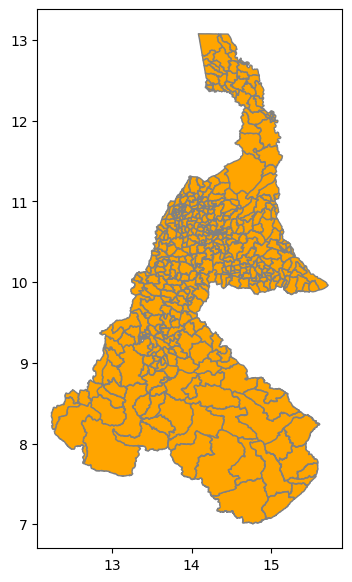

In [11]:
cameroon_shp.plot(facecolor="none", edgecolor='grey', figsize=(5,7), color='orange')

In [12]:
cameroon_shp['location'] = list(zip(cameroon_shp['GID0'], cameroon_shp['GID2'], cameroon_shp['GID3']))
cameroon_cases['location'] = list(zip(cameroon_cases['GID0'], cameroon_cases['GID2'], cameroon_cases['GID3']))

In [13]:
cameroon_cases

,GID0,GID2,GID3,dt_placement,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,location
0,extreme nord,bogo,balaza,2025-01,117,125,14,237,21,25,2,48,21,25,2,48,"(extreme nord, bogo, balaza)"
1,extreme nord,bogo,balda,2025-01,77,56,12,139,20,11,8,39,20,11,8,39,"(extreme nord, bogo, balda)"
2,extreme nord,bogo,bogo,2025-01,179,42,59,432,67,63,42,172,67,63,42,172,"(extreme nord, bogo, bogo)"
3,extreme nord,bogo,borai,2025-01,65,40,2,144,26,27,0,53,26,27,0,53,"(extreme nord, bogo, borai)"
4,extreme nord,bogo,guinggley,2025-01,104,0,23,173,32,9,9,50,32,9,9,50,"(extreme nord, bogo, guinggley)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6333,nord,touboro,mbeing,2025-12,102,0,9,167,18,13,0,31,18,13,0,31,"(nord, touboro, mbeing)"
6334,nord,touboro,ngay lara,2025-12,132,33,78,334,79,63,48,190,79,63,48,190,"(nord, touboro, ngay lara)"
6335,nord,touboro,touboro,2025-12,382,96,79,918,167,214,47,428,167,214,47,428,"(nord, touboro, touboro)"
6336,nord,touboro,vogzom,2025-12,129,5,65,374,44,71,27,142,44,71,27,142,"(nord, touboro, vogzom)"


In [14]:
missing_locations = cameroon_cases[~cameroon_cases['location'].isin(cameroon_shp['location'])]
missing_locations.location.sort_values().unique().shape

(139,)

In [15]:
missing_locations

,GID0,GID2,GID3,dt_placement,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,location
13,extreme nord,bourha,maboudji (pnlp),2025-01,0,37,2,4,0,1,2,3,0,1,2,3,"(extreme nord, bourha, maboudji (pnlp))"
14,extreme nord,bourha,mbola (bourha),2025-01,4,39,2,10,1,0,0,1,1,0,0,1,"(extreme nord, bourha, mbola (bourha))"
23,extreme nord,gazawa,dagai (gazawa),2025-01,20,42,3,40,12,4,1,17,12,4,1,17,"(extreme nord, gazawa, dagai (gazawa))"
25,extreme nord,gazawa,gazawa 1,2025-01,26,13,12,116,9,23,3,35,9,23,3,35,"(extreme nord, gazawa, gazawa 1)"
26,extreme nord,gazawa,gazawa 2,2025-01,11,9,0,19,8,3,0,11,8,3,0,11,"(extreme nord, gazawa, gazawa 2)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6317,nord,rey bouba,wafango (pnlp),2025-12,99,0,11,180,15,1,4,20,15,1,4,20,"(nord, rey bouba, wafango (pnlp))"
6330,nord,touboro,mbai mboum,2025-12,190,10,12,376,68,41,12,121,68,41,12,121,"(nord, touboro, mbai mboum)"
6331,nord,touboro,mbaka (touboro),2025-12,99,0,19,173,8,4,1,13,8,4,1,13,"(nord, touboro, mbaka (touboro))"
6332,nord,touboro,mbang rey,2025-12,67,0,9,161,7,13,5,25,7,13,5,25,"(nord, touboro, mbang rey)"


In [16]:
cameroon_shp['location'].unique().shape

(462,)

In [17]:
with open("locations_from_shapefile_2025.txt", "w", encoding="utf-8") as f:
    for item in cameroon_shp['location'].unique().tolist():
        f.write(f"{item}\n")

In [18]:
cameroon_cases['location'].unique().shape

(529,)

In [19]:
with open("locations_from_cases_2025.txt", "w", encoding="utf-8") as f:
    for item in cameroon_cases['location'].unique().tolist():
        f.write(f"{item}\n")

In [20]:
missing_locations['location'].unique().shape

(139,)

In [21]:
with open("locations_differences_2025.txt", "w", encoding="utf-8") as f:
    for item in missing_locations['location'].unique().tolist():
        f.write(f"{item}\n")

In [22]:
location_replacements = {
        ('extreme nord', 'bourha', 'maboudji (pnlp)'): ('extreme nord', 'bourha', 'maboudji'),
        ('extreme nord', 'bourha', 'mbola (bourha)'):('extreme nord', 'bourha', 'mbola bourha'),
        ('extreme nord', 'gazawa', 'dagai (gazawa)'):('extreme nord', 'gazawa', 'dagai'),
        ('extreme nord', 'gazawa', 'gazawa 1'):('extreme nord', 'gazawa', 'gazawa'),
        ('extreme nord', 'gazawa', 'gazawa 2'):('extreme nord', 'gazawa', 'gazawa'),
        ('extreme nord', 'goulfey', 'goulfey gana'):('extreme nord', 'goulfey', 'gana'),
        ('extreme nord', 'goulfey', 'ndjimini'):('extreme nord', 'goulfey', 'mara'),
        ('extreme nord', 'guere', 'bangana'):('extreme nord', 'guere', 'bagana'),
        ('extreme nord', 'guere', 'gobo 1'):('extreme nord', 'guere', 'gobo'),
        ('extreme nord', 'guere', 'gobo 2'):('extreme nord', 'guere', 'gobo'),
        ('extreme nord', 'guere', 'guiriou grand'):('extreme nord', 'guere', 'gobo'),
        ('extreme nord', 'guere', 'karam'):('extreme nord', 'guere', 'gobo'),
        ('extreme nord', 'guere', 'massa koutweita'):('extreme nord', 'guere', 'gobo'),
        ('extreme nord', 'guere', 'ngu ring'):('extreme nord', 'guere', 'gobo'),
        ('extreme nord', 'guere', 'ngu�ring'):('extreme nord', 'guere', 'gobo'),
        ('extreme nord', 'guidiguis', 'golondakri'):('extreme nord', 'guidiguis', 'touloum'),
        ('extreme nord', 'guidiguis', 'mandaigoum'):('extreme nord', 'guidiguis', 'dziguilao 2'),
        ('extreme nord', 'guidiguis', 'torock'):('extreme nord', 'guidiguis', 'guereme'),
        ('extreme nord', 'hina', 'djalingo (hina)'):('extreme nord', 'hina', 'hina'),
        ('extreme nord', 'hina', 'houva benzam'):('extreme nord', 'hina', 'gamdougoum'),
        ('extreme nord', 'kaele', 'doumrou (kaele)'):('extreme nord', 'kaele', 'doumrou'),
        ('extreme nord', 'kar hay', 'mogom (kar hay)'):('extreme nord', 'kar hay', 'mogom'),
        ('extreme nord', 'kar hay', 'oulargo'):('extreme nord', 'kar hay', 'doukoula 2'),
        ('extreme nord', 'kar hay', 'takreo-yoldeo'):('extreme nord', 'kar hay', 'takreo - yoldeo'), 
        ('extreme nord', 'kousseri', 'amchedire'):('extreme nord', 'kousseri', 'amchidire'),
        ('extreme nord', 'kousseri', 'hinale'):('extreme nord', 'kousseri', 'madiako'),
        ('extreme nord', 'kousseri', 'houlouf'):('extreme nord', 'kousseri', 'kalakafra'),
        ('extreme nord', 'kousseri', 'kodogo'):('extreme nord', 'kousseri', 'madana'),
        ('extreme nord', 'kousseri', 'zagara'):('extreme nord', 'kousseri', 'parpar'),
        ('extreme nord', 'koza', "gouzda-m'lay"):('extreme nord', 'koza', 'gouzda wayam'),
        ('extreme nord', 'koza', "m'tskar"):('extreme nord', 'koza', 'mstikar'),
        ('extreme nord', 'maga', 'keleo (pnlp)'):('extreme nord', 'maga', 'keleo'),
        ('extreme nord', 'maga', 'lahai (pnlp)'):('extreme nord', 'maga', 'lahai'),
        ('extreme nord', 'maga', 'ngoulmong (pnlp)'):('extreme nord', 'maga', 'ngoulmoung'),
        ('extreme nord', 'maga', 'palia (pnlp)'):('extreme nord', 'maga', 'palia'),
        ('extreme nord', 'makary', 'amchilga'):('extreme nord', 'makari', 'amchilga'),
        ('extreme nord', 'makary', 'biamo'):('extreme nord', 'makari', 'biamo'),
        ('extreme nord', 'makary', 'bodo'):('extreme nord', 'makari', 'bodo'),
        ('extreme nord', 'makary', 'bomboyo'):('extreme nord', 'makari', 'bomboyo'),
        ('extreme nord', 'makary', 'makary'):('extreme nord', 'makari', 'makari'),
        ('extreme nord', 'makary', 'ngouma'):('extreme nord', 'makari', 'ngouma'),
        ('extreme nord', 'makary', 'woulky'):('extreme nord', 'makari', 'woulky'),
        ('extreme nord', 'maroua 1', 'domayo kaigama 1'):('extreme nord', 'maroua 1', 'domayo kamanjo kaigama'),
        ('extreme nord', 'maroua 1', 'makabaye 1'):('extreme nord', 'maroua 1', 'makabaye'),
        ('extreme nord', 'maroua 2', 'dogba 1'):('extreme nord', 'maroua 2', 'dogba'),
        ('extreme nord', 'maroua 2', 'doualare 1'):('extreme nord', 'maroua 2', 'doualare'),
        ('extreme nord', 'maroua 2', 'lopere 1'):('extreme nord', 'maroua 2', 'lopere'),
        ('extreme nord', 'maroua 2', 'zokok 1'):('extreme nord', 'maroua 2', 'zokok'),
        ('extreme nord', 'maroua 3', 'dargala 1'):('extreme nord', 'maroua 3', 'dargala'),
        ('extreme nord', 'maroua 3', 'djarengol kodek'):('extreme nord', 'maroua 3', 'kodek'),
        ('extreme nord', 'maroua 3', 'kaheo'):('extreme nord', 'maroua 3', 'kaewo'),
        ('extreme nord', 'maroua 3', 'kongola'):('extreme nord', 'maroua 3', 'kengola'),
        ('extreme nord', 'meri', 'dougour-tchere (pnlp)'):('extreme nord', 'meri', 'doulek'),
        ('extreme nord', 'meri', 'douroum (meri)'):('extreme nord', 'meri', 'doumrou'),
        ('extreme nord', 'meri', 'houloum (pnlp)'):('extreme nord', 'meri', 'houloum'),
        ('extreme nord', 'meri', 'zalla (pnlp)'):('extreme nord', 'meri', 'zalla'),
        ('extreme nord', 'mindif', 'mogom (mindif)'):('extreme nord', 'mindif', 'mogom'),
        ('extreme nord', 'mokolo', 'gouloua mombo '):('extreme nord', 'mokolo', 'gouloua momboi'),
        ('extreme nord', 'mokolo', 'gouloua mombo�'):('extreme nord', 'mokolo', 'gouloua momboi'),
        ('extreme nord', 'mokolo', 'kilwo'):('extreme nord', 'mokolo', 'mokolo 2'),
        ('extreme nord', 'mokolo', 'ldamtsai goda'):('extreme nord', 'mokolo', 'goda ldamtsai'),
        ('extreme nord', 'mokolo', 'mandaka'):('extreme nord', 'mokolo', 'mandaka chechem'),
        ('extreme nord', 'mokolo', 'mokolo 1 (mokolo)'):('extreme nord', 'mokolo', 'mokolo 1'),
        ('extreme nord', 'mokolo', 'mokong centre'):('extreme nord', 'mokolo', 'mokong'),
        ('extreme nord', 'mokolo', 'mounhour'):('extreme nord', 'mokolo', 'mouhour'),
        ('extreme nord', 'mokolo', 'tchouvouk (pnlp)'):('extreme nord', 'mokolo', 'tchouvouk'),
        ('extreme nord', 'mokolo', 'zamay publique'):('extreme nord', 'mokolo', 'zamay grede'),
        ('extreme nord', 'mora', 'djounde'):('extreme nord', 'mora', 'djaounde'),
        ('extreme nord', 'mora', 'oudjilla'):('extreme nord', 'mora', 'oudjila'),
        ('extreme nord', 'moulvoudaye', 'doukoureye'):('extreme nord', 'moulvoudaye', 'manga'),
        ('extreme nord', 'moulvoudaye', 'kobo'):('extreme nord', 'moulvoudaye', 'manga'),
        ('extreme nord', 'moulvoudaye', 'mbitchare'):('extreme nord', 'moulvoudaye', 'manga'),
        ('extreme nord', 'moulvoudaye', 'moditane'):('extreme nord', 'moulvoudaye', 'manga'),
        ('extreme nord', 'moutourwa', 'foulou'):('extreme nord', 'moutourwa', 'damai'),
        ('extreme nord', 'mozogo', 'nguetchewe'):('extreme nord', 'mozogo', 'nghetchewe'),
        ('extreme nord', 'mozogo', 'oupa -manak'):('extreme nord', 'mozogo', 'ouzal'),
        ('extreme nord', 'mozogo', 'oupa�-manak'):('extreme nord', 'mozogo', 'ouzal'),
        ('extreme nord', 'roua', 'golibai (pnlp)'):('extreme nord', 'roua', 'golibai'),
        ('extreme nord', 'roua', 'zogom (pnlp)'):('extreme nord', 'roua', 'zogom'),
        ('extreme nord', 'tokombere', 'mada kolkoch'):('extreme nord', 'tokombere', 'mada-kolkoch'),
        ('extreme nord', 'tokombere', 'mangave dalil'):('extreme nord', 'tokombere', 'mangave - dalil'),
        ('extreme nord', 'tokombere', 'ouro chetima'):('extreme nord', 'tokombere', 'mokio'),
        ('extreme nord', 'tokombere', 'seradoumda'):('extreme nord', 'tokombere', 'palbara'),
        ('extreme nord', 'vele', 'kouro mokdaye'):('extreme nord', 'vele', 'kouromokdaye'),
        ('extreme nord', 'waza', 'waza'):('extreme nord', 'mora', 'waza'),
        ('extreme nord', 'waza', 'zigague'):('extreme nord', 'mora', 'zigague'),
        ('extreme nord', 'yagoua', 'bosgoye'):('extreme nord', 'yagoua', 'bougaye'),
        ('extreme nord', 'yagoua', 'dabaye'):('extreme nord', 'yagoua', 'bougaye'),
        ('extreme nord', 'yagoua', 'domo'):('extreme nord', 'yagoua', 'djongdong'),
        ('extreme nord', 'yagoua', 'guinane'):('extreme nord', 'yagoua', 'gobio'),
        ('extreme nord', 'yagoua', 'miogoye'):('extreme nord', 'yagoua', 'mass gaya'),
        ('extreme nord', 'yagoua', 'thiou'):('extreme nord', 'yagoua', 'mass gaya'),
        ('extreme nord', 'yagoua', 'yagoua 1'):('extreme nord', 'yagoua', 'yagoua'),
        ('extreme nord', 'yagoua', 'yagoua 2'):('extreme nord', 'yagoua', 'yagoua'),
        ('extreme nord', 'yagoua', 'yagoua 3'):('extreme nord', 'yagoua', 'yagoua'),
        ('nord', 'bibemi', 'douloumi'):('nord', 'bibemi', 'mbella'),
        ('nord', 'bibemi', 'hamalad '):('nord', 'bibemi', 'houla'),
        ('nord', 'bibemi', 'hamalad�'):('nord', 'bibemi', 'houla'),
        ('nord', 'bibemi', 'lam (bibemi)'):('nord', 'bibemi', 'lam'),
        ('nord', 'bibemi', 'lombo'):('nord', 'bibemi', 'lam'),
        ('nord', 'figuil', 'biou'):('nord', 'figuil', 'bidzar'),
        ('nord', 'figuil', 'kong kong '):('nord', 'figuil', 'figuil'),
        ('nord', 'figuil', 'lam (figuil)'):('nord', 'figuil', 'lam'),
        ('nord', 'figuil', 'pelgue'):('nord', 'figuil', 'lam'),
        ('nord', 'garoua 1', ' as souari 2'):('nord', 'garoua 1', 'kollere'),
        ('nord', 'garoua 1', 'bangli'):('nord', 'garoua 1', 'djamboutou'),
        ('nord', 'garoua 1', 'djamboutou 2'):('nord', 'garoua 1', 'djamboutou'),
        ('nord', 'garoua 1', 'mayami'):('nord', 'garoua 1', 'djamboutou'),
        ('nord', 'garoua 1', 'nakong'):('nord', 'garoua 1', 'ouro kanadi'),
        ('nord', 'garoua 1', 'ouro-kanadi 2 '):('nord', 'garoua 1', 'ouro kanadi'),
        ('nord', 'garoua 1', 'ouro-malamadou '):('nord', 'garoua 1', 'ouro labo'),
        ('nord', 'garoua 1', 'souari'):('nord', 'garoua 1', 'ouro kanadi'),
        ('nord', 'garoua 1', 'tcharatch '):('nord', 'garoua 1', 'ouro labo'),
        ('nord', 'garoua 1', 'tcharatch�'):('nord', 'garoua 1', 'ouro labo'),
        ('nord', 'garoua 2', 'kotta liddire'):('nord', 'garoua 2', 'takasko'),
        ('nord', 'garoua 2', 'ngalbidje'):('nord', 'garoua 2', 'roumde adjia'),
        ('nord', 'gaschiga', 'barndake'):('nord', 'gaschiga', 'barndake 2'),
        ('nord', 'guider', 'beli'):('nord', 'guider', 'libe'),
        ('nord', 'guider', 'mayo loue '):('nord', 'guider', 'matafal'),
        ('nord', 'guider', 'ouro-tara '):('nord', 'guider', 'balga'),
        ('nord', 'lagdo', 'bajaoul '):('nord', 'lagdo', 'badankali'),
        ('nord', 'lagdo', 'bajaoul�'):('nord', 'lagdo', 'badankali'),
        ('nord', 'lagdo', 'kat '):('nord', 'lagdo', 'gounougou'),
        ('nord', 'lagdo', 'kat�'):('nord', 'lagdo', 'gounougou'),
        ('nord', 'lagdo', 'lagdo'):('nord', 'lagdo', 'gounougou'),
        ('nord', 'lagdo', 'naari'):('nord', 'lagdo', "na'ari"),
        ('nord', 'lagdo', 'tongo (lagdo)'):('nord', 'lagdo', 'tongo'), 
        ('nord', 'ngong', 'bockl '):('nord', 'ngong', 'badang'),
        ('nord', 'ngong', 'bockl�'):('nord', 'ngong', 'badang'),
        ('nord', 'ngong', 'boumedje'):('nord', 'ngong', 'djalingo'),
        ('nord', 'ngong', 'djalingo (ngong)'):('nord', 'ngong', 'djalingo'),
        ('nord', 'ngong', 'haigadewa'):('nord', 'ngong', 'djefatou'),
        ('nord', 'ngong', 'ouro-s k hi'):('nord', 'ngong', 'ngong'),
        ('nord', 'ngong', 'ouro-s�k�hi'):('nord', 'ngong', 'ngong'),
        ('nord', 'ngong', 'winde-ngong (pnlp)'):('nord', 'ngong', 'touroua'),
        ('nord', 'pitoa', 'dolla'):('nord', 'pitoa', 'dola'),
        ('nord', 'poli', 'beka 2'):('nord', 'poli', 'beka'),
        ('nord', 'poli', 'bimba (poli)'):('nord', 'poli', 'bimba'), 
        ('nord', 'poli', 'poli rural (pnlp)'):('nord', 'poli', 'poli'),
        ('nord', 'poli', 'sirdjam'):('nord', 'poli', 'poli'),
        ('nord', 'poli', 'tapare (poli)'):('nord', 'poli', 'tapare'),
        ('nord', 'poli', 'tchamba (poli)'):('nord', 'poli', 'tchamba'),
        ('nord', 'rey bouba', 'landou (pnlp)'):('nord', 'rey bouba', 'kong rong'),
        ('nord', 'rey bouba', 'wafango (pnlp)'):('nord', 'rey bouba', 'dobinga'),
        ('nord', 'touboro', 'mbai mboum'):('nord', 'touboro', 'mbai-mboum'),
        ('nord', 'touboro', 'mbaka (touboro)'):('nord', 'touboro', 'mbaka'),
        ('nord', 'touboro', 'mbang rey'):('nord', 'touboro', 'mbang-rey'),
        ('nord', 'touboro', 'ngay lara'):('nord', 'touboro', 'ngai-lara'), 
    }


In [23]:
# Apply the replacements
cameroon_cases['location'] = cameroon_cases['location'].apply(lambda x: location_replacements.get(x, x))

In [24]:
missing_locations = cameroon_cases[~cameroon_cases['location'].isin(cameroon_shp['location'])]
missing_locations.location.sort_values().unique().shape

(0,)

In [25]:
pd.Series(missing_locations['location'].unique(), name="Locations").sort_values()

Series([], Name: Locations, dtype: object)

In [26]:
cameroon_cases.shape

(6338, 17)

In [27]:
pair_counts = cameroon_cases.groupby(['location', 'dt_placement']).size().reset_index(name='count')
pair_counts['count'].max()

6

In [28]:
summed_cameroon_cases = cameroon_cases.groupby(['location', 'dt_placement']).sum().reset_index()
summed_cameroon_cases.sort_values(by=['dt_placement', 'location'], inplace=True)
summed_cameroon_cases.reset_index(drop=True, inplace=True)
summed_cameroon_cases.head()

,location,dt_placement,GID0,GID2,GID3,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL
0,"(extreme nord, bogo, balaza)",2025-01,extreme nord,bogo,balaza,117,125,14,237,21,25,2,48,21,25,2,48
1,"(extreme nord, bogo, balda)",2025-01,extreme nord,bogo,balda,77,56,12,139,20,11,8,39,20,11,8,39
2,"(extreme nord, bogo, bogo)",2025-01,extreme nord,bogo,bogo,179,42,59,432,67,63,42,172,67,63,42,172
3,"(extreme nord, bogo, borai)",2025-01,extreme nord,bogo,borai,65,40,2,144,26,27,0,53,26,27,0,53
4,"(extreme nord, bogo, guinggley)",2025-01,extreme nord,bogo,guinggley,104,0,23,173,32,9,9,50,32,9,9,50


In [29]:
pair_counts_summed = summed_cameroon_cases.groupby(['location', 'dt_placement']).size().reset_index(name='count')
pair_counts_summed['count'].max()

1

In [30]:
for col in case_columns:
    print(f"Total {col}: {cameroon_cases[col].sum():,}")

Total Case_UND5: 350,378
Total Case_OVR5: 384,153
Total Case_PRGN: 62,063
Total Case_TOTAL: 796,663
Total Sevr_UND5: 80,140
Total Sevr_OVR5: 83,888
Total Sevr_PRGN: 28,995
Total Sevr_TOTAL: 193,023
Total Hosp_UND5: 80,140
Total Hosp_OVR5: 83,888
Total Hosp_PRGN: 28,995
Total Hosp_TOTAL: 193,023


In [31]:
for col in case_columns:
    print(f"Total {col}: {summed_cameroon_cases[col].sum():,}")

Total Case_UND5: 350,378
Total Case_OVR5: 384,153
Total Case_PRGN: 62,063
Total Case_TOTAL: 796,663
Total Sevr_UND5: 80,140
Total Sevr_OVR5: 83,888
Total Sevr_PRGN: 28,995
Total Sevr_TOTAL: 193,023
Total Hosp_UND5: 80,140
Total Hosp_OVR5: 83,888
Total Hosp_PRGN: 28,995
Total Hosp_TOTAL: 193,023


In [32]:
summed_cameroon_cases.shape

(5466, 17)

In [33]:
summed_cameroon_cases[['GID0', 'GID2', 'GID3']] = pd.DataFrame(summed_cameroon_cases['location'].tolist(), index=summed_cameroon_cases.index)

In [34]:
missing_gid2 = summed_cameroon_cases[~summed_cameroon_cases['GID2'].isin(cameroon_shp['GID2'])]
missing_gid3 = summed_cameroon_cases[~summed_cameroon_cases['GID3'].isin(cameroon_shp['GID3'])]

In [35]:
missing_gid2.GID2.sort_values().unique()

array([], dtype=object)

In [36]:
missing_gid3.GID3.sort_values().unique()

array([], dtype=object)

In [37]:
cameroon_shp.head()

,GID3,GID2,GID1,GID0,geometry,location
0,gor,tchollire,mayo-rey,nord,"POLYGON ((14.82946 8.80523, 14.82959 8.80542, ...","(nord, tchollire, gor)"
1,kali,tchollire,mayo-rey,nord,"POLYGON ((14.25497 8.47303, 14.25528 8.47297, ...","(nord, tchollire, kali)"
2,tchollire,tchollire,mayo-rey,nord,"POLYGON ((14.10170 8.52491, 14.10191 8.52468, ...","(nord, tchollire, tchollire)"
3,gamba,tchollire,mayo-rey,nord,"POLYGON ((13.73985 8.05249, 13.74000 8.05274, ...","(nord, tchollire, gamba)"
4,sakdje,tchollire,mayo-rey,nord,"POLYGON ((13.61775 8.35648, 13.61863 8.35606, ...","(nord, tchollire, sakdje)"


In [38]:
summed_cameroon_cases.head()

,location,dt_placement,GID0,GID2,GID3,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL
0,"(extreme nord, bogo, balaza)",2025-01,extreme nord,bogo,balaza,117,125,14,237,21,25,2,48,21,25,2,48
1,"(extreme nord, bogo, balda)",2025-01,extreme nord,bogo,balda,77,56,12,139,20,11,8,39,20,11,8,39
2,"(extreme nord, bogo, bogo)",2025-01,extreme nord,bogo,bogo,179,42,59,432,67,63,42,172,67,63,42,172
3,"(extreme nord, bogo, borai)",2025-01,extreme nord,bogo,borai,65,40,2,144,26,27,0,53,26,27,0,53
4,"(extreme nord, bogo, guinggley)",2025-01,extreme nord,bogo,guinggley,104,0,23,173,32,9,9,50,32,9,9,50


In [39]:
cameroon_cases_temp = summed_cameroon_cases.copy()

In [40]:
cameroon_cases_temp['dt_placement'] = pd.to_datetime(cameroon_cases_temp['dt_placement'], format='%Y-%m')
cameroon_cases_temp['year'] = cameroon_cases_temp['dt_placement'].dt.year
cameroon_cases_temp['month'] = cameroon_cases_temp['dt_placement'].dt.month
cameroon_cases_temp.drop(columns=['location', 'dt_placement'], inplace=True)

In [41]:
cameroon_cases_grouped_year = (cameroon_cases_temp
                                .groupby(['GID3', 'GID2', 'GID0', 'year'], as_index=False)
                                .sum().reset_index())

In [42]:
cameroon_cases_grouped_total = (cameroon_cases_temp
                                .groupby(['GID3', 'GID2', 'GID0'], as_index=False)
                                .sum().reset_index())

In [43]:
for col in case_columns:
    print(f"Total {col}: {cameroon_cases_grouped_year[col].sum():,}")

Total Case_UND5: 350,378
Total Case_OVR5: 384,153
Total Case_PRGN: 62,063
Total Case_TOTAL: 796,663
Total Sevr_UND5: 80,140
Total Sevr_OVR5: 83,888
Total Sevr_PRGN: 28,995
Total Sevr_TOTAL: 193,023
Total Hosp_UND5: 80,140
Total Hosp_OVR5: 83,888
Total Hosp_PRGN: 28,995
Total Hosp_TOTAL: 193,023


In [44]:
for col in case_columns:
    print(f"Total {col}: {cameroon_cases_grouped_total[col].sum():,}")

Total Case_UND5: 350,378
Total Case_OVR5: 384,153
Total Case_PRGN: 62,063
Total Case_TOTAL: 796,663
Total Sevr_UND5: 80,140
Total Sevr_OVR5: 83,888
Total Sevr_PRGN: 28,995
Total Sevr_TOTAL: 193,023
Total Hosp_UND5: 80,140
Total Hosp_OVR5: 83,888
Total Hosp_PRGN: 28,995
Total Hosp_TOTAL: 193,023


In [45]:
cameroon_cases_grouped_year.drop(columns=['index', 'month'], inplace=True)

In [46]:
cameroon_cases_grouped_total.drop(columns=['index', 'month', 'year'], inplace=True)

In [47]:
cm_cases_shp = cameroon_shp.merge(cameroon_cases_grouped_year, on=[ 'GID0', 'GID2', 'GID3'], how="right")

In [48]:
cm_cases_shp_total = cameroon_shp.merge(cameroon_cases_grouped_total, on=[ 'GID0', 'GID2', 'GID3'], how="right")

In [49]:
for col in case_columns:
    print(f"Total {col}: {cm_cases_shp[col].sum():,}")

Total Case_UND5: 350,378
Total Case_OVR5: 384,153
Total Case_PRGN: 62,063
Total Case_TOTAL: 796,663
Total Sevr_UND5: 80,140
Total Sevr_OVR5: 83,888
Total Sevr_PRGN: 28,995
Total Sevr_TOTAL: 193,023
Total Hosp_UND5: 80,140
Total Hosp_OVR5: 83,888
Total Hosp_PRGN: 28,995
Total Hosp_TOTAL: 193,023


In [50]:
for col in case_columns:
    print(f"Total {col}: {cm_cases_shp_total[col].sum():,}")

Total Case_UND5: 350,378
Total Case_OVR5: 384,153
Total Case_PRGN: 62,063
Total Case_TOTAL: 796,663
Total Sevr_UND5: 80,140
Total Sevr_OVR5: 83,888
Total Sevr_PRGN: 28,995
Total Sevr_TOTAL: 193,023
Total Hosp_UND5: 80,140
Total Hosp_OVR5: 83,888
Total Hosp_PRGN: 28,995
Total Hosp_TOTAL: 193,023


In [51]:
cm_cases_shp.rename(columns={"Case_UND5": "Case_U5", "Case_OVR5": "Case_O5", "Case_PRGN": "Case_PR", "Case_TOTAL" : "Case_TO",
                                                "Sevr_UND5": "Sevr_U5", "Sevr_OVR5": "Sevr_O5", "Sevr_PRGN": "Sevr_PR", "Sevr_TOTAL" : "Sevr_TO",
                                                "Hosp_UND5": "Hosp_U5", "Hosp_OVR5": "Hosp_O5", "Hosp_PRGN": "Hosp_PR", "Hosp_TOTAL" : "Hosp_TO",
                                                "Death_UND5": "Dead_U5", "Death_OVR5": "Dead_O5", "Death_PRGN": "Dead_PR", "Death_TOTAL" : "Dead_TO"}, inplace = True)

In [52]:
cm_cases_shp_total.rename(columns={"Case_UND5": "Case_U5", "Case_OVR5": "Case_O5", "Case_PRGN": "Case_PR", "Case_TOTAL" : "Case_TO",
                                                "Sevr_UND5": "Sevr_U5", "Sevr_OVR5": "Sevr_O5", "Sevr_PRGN": "Sevr_PR", "Sevr_TOTAL" : "Sevr_TO",
                                                "Hosp_UND5": "Hosp_U5", "Hosp_OVR5": "Hosp_O5", "Hosp_PRGN": "Hosp_PR", "Hosp_TOTAL" : "Hosp_TO",
                                                "Death_UND5": "Dead_U5", "Death_OVR5": "Dead_O5", "Death_PRGN": "Dead_PR", "Death_TOTAL" : "Dead_TO"}, inplace = True)

In [53]:
cm_cases_shp.head(3)

,GID3,GID2,GID1,GID0,geometry,location,year,Case_U5,Case_O5,Case_PR,Case_TO,Sevr_U5,Sevr_O5,Sevr_PR,Sevr_TO,Hosp_U5,Hosp_O5,Hosp_PR,Hosp_TO
0,adoumri,bibemi,benoue,nord,"POLYGON ((13.79028 9.30949, 13.79040 9.30947, ...","(nord, bibemi, adoumri)",2025,702,1147,181,1413,165,115,48,328,165,115,48,328
1,afade,goulfey,logone et chari,extreme nord,"POLYGON ((14.54828 12.23823, 14.54801 12.23914...","(extreme nord, goulfey, afade)",2025,442,328,110,1050,90,172,18,280,90,172,18,280
2,aissa harde,mora,mayo-sava,extreme nord,"POLYGON ((14.20358 11.17270, 14.20447 11.17190...","(extreme nord, mora, aissa harde)",2025,2097,482,39,2999,164,86,24,274,164,86,24,274


In [54]:
cm_cases_shp_total.head(3)

,GID3,GID2,GID1,GID0,geometry,location,Case_U5,Case_O5,Case_PR,Case_TO,Sevr_U5,Sevr_O5,Sevr_PR,Sevr_TO,Hosp_U5,Hosp_O5,Hosp_PR,Hosp_TO
0,adoumri,bibemi,benoue,nord,"POLYGON ((13.79028 9.30949, 13.79040 9.30947, ...","(nord, bibemi, adoumri)",702,1147,181,1413,165,115,48,328,165,115,48,328
1,afade,goulfey,logone et chari,extreme nord,"POLYGON ((14.54828 12.23823, 14.54801 12.23914...","(extreme nord, goulfey, afade)",442,328,110,1050,90,172,18,280,90,172,18,280
2,aissa harde,mora,mayo-sava,extreme nord,"POLYGON ((14.20358 11.17270, 14.20447 11.17190...","(extreme nord, mora, aissa harde)",2097,482,39,2999,164,86,24,274,164,86,24,274


In [55]:
cm_cases_shp.drop(columns=['location'], inplace=True)
cm_cases_shp_total.drop(columns=['location'], inplace=True)

In [56]:
cm_cases_shp.shape

(456, 18)

In [57]:
cm_cases_shp_total.shape

(456, 17)

In [58]:
cm_cases_shp = cm_cases_shp[['GID0', 'GID1', 'GID2', 'GID3', 'year', 
                             'Case_U5', 'Case_O5', 'Case_PR', 'Case_TO',
                             'Sevr_U5', 'Sevr_O5', 'Sevr_PR', 'Sevr_TO',
                             'Hosp_U5', 'Hosp_O5', 'Hosp_PR', 'Hosp_TO',
                             #'Dead_U5', 'Dead_O5', 'Dead_PR', 'Dead_TO',
                             'geometry']]

In [59]:
cm_cases_shp_total = cm_cases_shp_total[['GID0', 'GID1', 'GID2', 'GID3', 
                             'Case_U5', 'Case_O5', 'Case_PR', 'Case_TO',
                             'Sevr_U5', 'Sevr_O5', 'Sevr_PR', 'Sevr_TO',
                             'Hosp_U5', 'Hosp_O5', 'Hosp_PR', 'Hosp_TO',
                             #'Dead_U5', 'Dead_O5', 'Dead_PR', 'Dead_TO',
                             'geometry']]

In [60]:
cm_cases_shp.shape

(456, 18)

In [61]:
cm_cases_shp_total.shape

(456, 17)

In [62]:
cm_cases_shp.sort_values(by=['GID0', 'GID1', 'GID2', 'GID3', 'year'], ascending=True, inplace=True)
cm_cases_shp.reset_index(drop=True, inplace=True)

cm_cases_shp_total.sort_values(by=['GID0', 'GID1', 'GID2', 'GID3'], ascending=True, inplace=True)
cm_cases_shp_total.reset_index(drop=True, inplace=True)

In [63]:
summed_cameroon_cases.drop(columns=['location'], inplace=True)

In [64]:
summed_cameroon_cases

,dt_placement,GID0,GID2,GID3,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL
0,2025-01,extreme nord,bogo,balaza,117,125,14,237,21,25,2,48,21,25,2,48
1,2025-01,extreme nord,bogo,balda,77,56,12,139,20,11,8,39,20,11,8,39
2,2025-01,extreme nord,bogo,bogo,179,42,59,432,67,63,42,172,67,63,42,172
3,2025-01,extreme nord,bogo,borai,65,40,2,144,26,27,0,53,26,27,0,53
4,2025-01,extreme nord,bogo,guinggley,104,0,23,173,32,9,9,50,32,9,9,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5461,2025-12,nord,touboro,mbeing,102,0,9,167,18,13,0,31,18,13,0,31
5462,2025-12,nord,touboro,ngai-lara,132,33,78,334,79,63,48,190,79,63,48,190
5463,2025-12,nord,touboro,touboro,382,96,79,918,167,214,47,428,167,214,47,428
5464,2025-12,nord,touboro,vogzom,129,5,65,374,44,71,27,142,44,71,27,142


In [65]:
summed_cameroon_cases.to_csv(f"{case_path}CM_MAL_cases_GID2_2025_fixed.csv", index=False, encoding=enc)

In [66]:
cm_cases_shp.to_file(f"{shapefile_path}CM_MAL_cases_2025_annual.shp", encoding=enc)

In [67]:
cm_cases_shp_total.to_file(f"{shapefile_path}CM_MAL_cases_2025_total.shp", encoding=enc)